# Laboratorio 7 (1-2)
## Grupo 1

### Importación de librerías.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

### Importación de datos.

In [2]:
df = pd.read_csv(r'C:\Users\ajmac\Documents\Universidad\Noveno semestre\Data Mining\Laboratorio 7\LABORATORIO_7_MD\datos_limpios.csv')
df.head(2)

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,97.0,2,...,0,0,0,0,1,0,0,0,0,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,160.0,3,...,0,0,0,0,1,0,0,0,0,0


### Estadísticas del objetivo.

In [3]:
df['price'].describe()

count    73549.000000
mean       769.542958
std       4326.270197
min          8.000000
25%        120.000000
50%        194.000000
75%        330.000000
max      50123.000000
Name: price, dtype: float64

### Manejo de NaN

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73549 entries, 0 to 164211
Data columns (total 67 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_listings_count                           73549 non-null  float64
 1   host_total_listings_count                     73549 non-null  float64
 2   latitude                                      73549 non-null  float64
 3   longitude                                     73549 non-null  float64
 4   accommodates                                  73549 non-null  int64  
 5   bathrooms                                     73549 non-null  float64
 6   bedrooms                                      73549 non-null  float64
 7   beds                                          73549 non-null  float64
 8   price                                         73549 non-null  float64
 9   minimum_nights                                73549 non-null  int

### Se reemplazará los NaN por las medianas.

In [5]:
df = df.fillna(df.median(numeric_only=True))

Las categorías se harán a partir de los cuartiles. Aquellas que estén debajo del cuartil 1 se denominarán 'Económicas', las que estén entre el primer y el tercer cuartil se denominarán 'Intermedia' y el resto 'Cara'.

### Se crea la categoría y se elimina la variable price.

In [6]:
categoria = []
for x in df['price']:
    if x <= 120:
        categoria.append('Económica')
    elif x < 330:
        categoria.append('Intermedia')
    else:
        categoria.append('Cara')
df = df.drop(columns=['price'])
df['categoria'] = categoria

### Volviendo númerica las categorías de precio. (Inciso 1)

In [7]:
dummies = pd.get_dummies(df['categoria'], dtype=int)
df = pd.concat([df, dummies], axis=1)
df = df.drop(columns=['categoria'])
df.head(2)

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,...,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30,Cara,Económica,Intermedia
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,2,90,...,0,1,0,0,0,0,0,0,1,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,3,365,...,0,1,0,0,0,0,0,0,0,1


### Separación de datos. (Inciso 2)

In [8]:
# Crear variable objetivo binaria: 1 si es 'Cara', 0 si no lo es
y_binario = df['Cara']

# Eliminar las variables objetivo del conjunto de características para evitar fuga de datos
X = df.drop(columns=['Cara', 'Económica', 'Intermedia'])

# Separación de datos (Fijando random_state=0 para reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(X, y_binario, test_size=0.2, random_state=0, stratify=y_binario)

### Inciso 3

In [9]:
# Se inicializa el modelo. max_iter se aumenta para asegurar que el algoritmo converja con muchos datos
modelo_logistico = LogisticRegression(random_state=0, max_iter=5000)

# Validación cruzada con 5 divisiones (folds) en el conjunto de entrenamiento
puntuaciones_cv = cross_val_score(modelo_logistico, X_train, y_train, cv=5, scoring='accuracy')

print("Puntuaciones de Validación Cruzada (Precisión):", puntuaciones_cv)
print(f"Precisión promedio en entrenamiento (CV): {np.mean(puntuaciones_cv):.4f}")

# Entrenamos el modelo con todo el conjunto de entrenamiento para los siguientes incisos
modelo_logistico.fit(X_train, y_train)

c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

Puntuaciones de Validación Cruzada (Precisión): [0.86012916 0.83769545 0.85027192 0.82681849 0.83445228]
Precisión promedio en entrenamiento (CV): 0.8419


c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

### Inciso 4

c:\Users\ajmac\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\ajmac\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Error al ajustar el modelo estadístico (posible colinealidad perfecta): Singular matrix


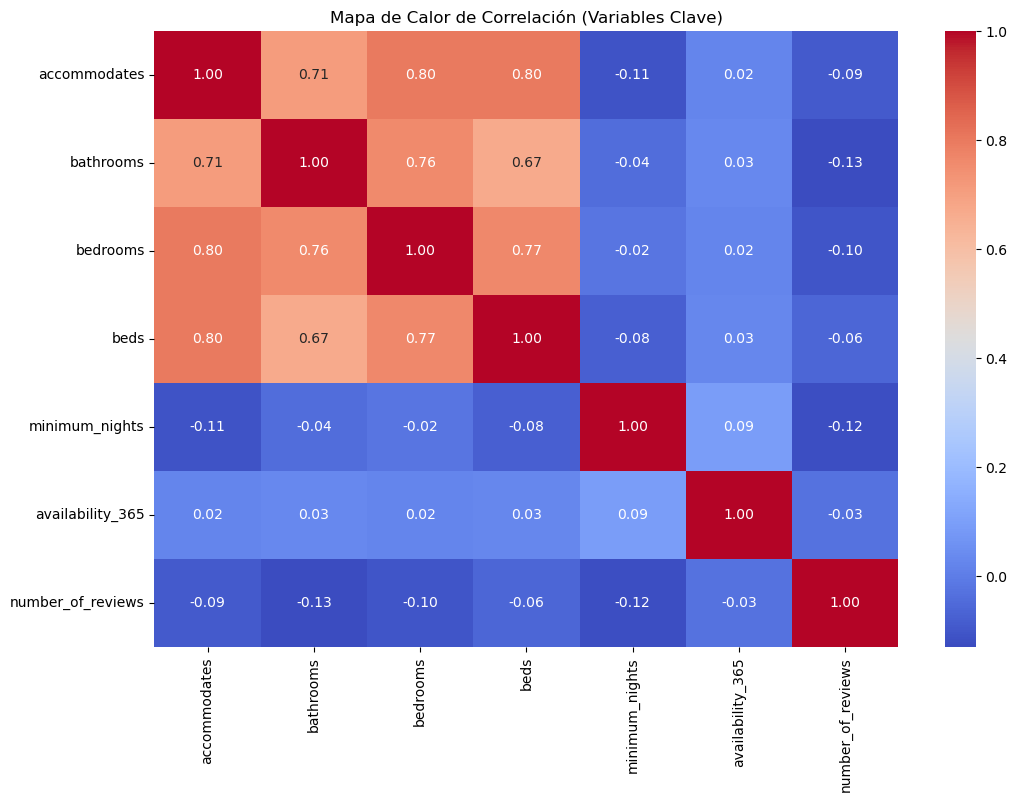

\nAnálisis de Multicolinealidad (VIF):\n             Variable        VIF
0       accommodates  13.066964
1          bathrooms   8.949654
2           bedrooms  10.357121
3               beds   8.053428
4     minimum_nights   1.197339
5   availability_365   3.177310
6  number_of_reviews   1.250292


In [10]:
# 1. Análisis de Significación (Valores p) usando statsmodels
# Es necesario agregar una constante para el término de intersección
X_train_sm = sm.add_constant(X_train)

# Evitamos errores por valores infinitos o nulos convirtiendo a float
X_train_sm = X_train_sm.astype(float)
y_train_sm = y_train.astype(float)

try:
    modelo_est = sm.Logit(y_train_sm, X_train_sm).fit(disp=0)
    print(modelo_est.summary())
except Exception as e:
    print("Error al ajustar el modelo estadístico (posible colinealidad perfecta):", e)

# 2. Análisis de Correlación
plt.figure(figsize=(12, 8))
# Seleccionamos algunas variables numéricas clave para que el mapa de calor sea legible
columnas_clave = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'availability_365', 'number_of_reviews']
sns.heatmap(X_train[columnas_clave].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor de Correlación (Variables Clave)")
plt.show()

# 3. Multicolinealidad (VIF)
# Se calcula el VIF para las variables numéricas clave (VIF > 5 o 10 indica alta multicolinealidad)
vif_data = pd.DataFrame()
vif_data["Variable"] = columnas_clave
vif_data["VIF"] = [variance_inflation_factor(X_train[columnas_clave].values, i) 
                   for i in range(len(columnas_clave))]
print("\\nAnálisis de Multicolinealidad (VIF):\\n", vif_data)

Podemos ver que hay una correlación entre 'acommodates' y 'bathrooms', 'acommodates' y 'bedrooms', 'acommadates' y  'beds'.

### Inciso 5

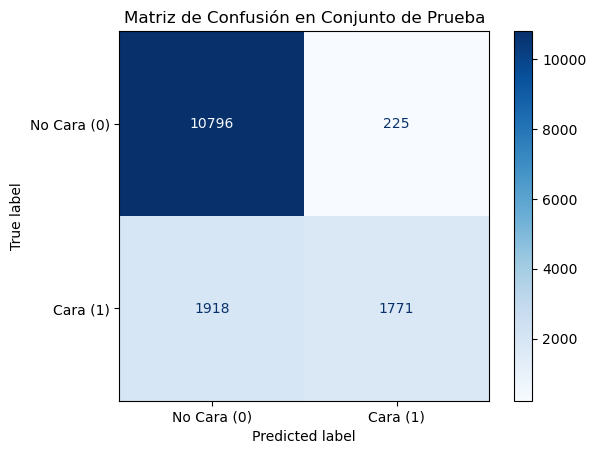

\nReporte de Eficiencia de Clasificación:\n
              precision    recall  f1-score   support

           0       0.85      0.98      0.91     11021
           1       0.89      0.48      0.62      3689

    accuracy                           0.85     14710
   macro avg       0.87      0.73      0.77     14710
weighted avg       0.86      0.85      0.84     14710



In [11]:
# Predicciones con el umbral de 0.5 (default)
y_pred_test = modelo_logistico.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cara (0)', 'Cara (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión en Conjunto de Prueba")
plt.show()

# Reporte de clasificación
print("\\nReporte de Eficiencia de Clasificación:\\n")
print(classification_report(y_test, y_pred_test))

Dado que queremos mínimizar el error tipo II nos centraremos en el recall por lo que al observar esta métrica para las casas caras podemos ver que es 0.48 lo cual podemos decir que el modelo no es del todo eficiente. 

### Inciso 6

Error en Conjunto de Entrenamiento: 0.1458
Error en Conjunto de Prueba:      0.1457
Conclusión: No hay sobreajuste (incluso rinde mejor o igual en prueba).


c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1243, in fit
    raise ValueE

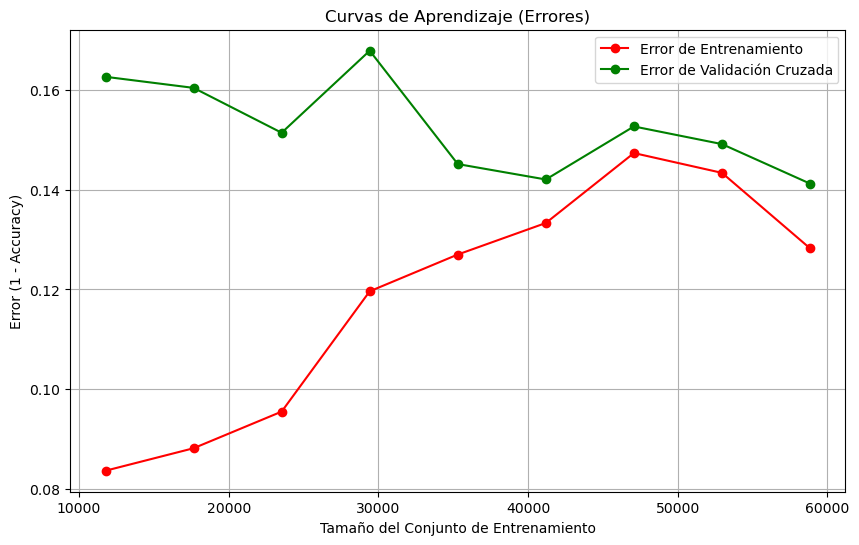

In [15]:
# Calcular Errores
acc_train = modelo_logistico.score(X_train, y_train)
acc_test = modelo_logistico.score(X_test, y_test)

error_train = 1 - acc_train
error_test = 1 - acc_test

print(f"Error en Conjunto de Entrenamiento: {error_train:.4f}")
print(f"Error en Conjunto de Prueba:      {error_test:.4f}")

if error_test > error_train + 0.05: # Umbral heurístico
    print("Conclusión: Existe evidencia de sobreajuste (Overfitting).")
elif error_test > error_train:
    print("Conclusión: El modelo generaliza bien, el ligero aumento del error en prueba es normal.")
else:
    print("Conclusión: No hay sobreajuste (incluso rinde mejor o igual en prueba).")

# Generar Curva de Aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(random_state=0, max_iter=5000), 
    X, y_binario, cv=5, scoring='accuracy', 
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calcular medias y desviaciones estándar
train_err_mean = 1 - np.mean(train_scores, axis=1)
test_err_mean = 1 - np.mean(test_scores, axis=1)

# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_err_mean, 'o-', color="red", label="Error de Entrenamiento")
plt.plot(train_sizes, test_err_mean, 'o-', color="green", label="Error de Validación Cruzada")
plt.title("Curvas de Aprendizaje (Errores)")
plt.xlabel("Tamaño del Conjunto de Entrenamiento")
plt.ylabel("Error (1 - Accuracy)")
plt.legend(loc="best")
plt.grid()
plt.show()